In [1]:
import torch
import numpy as np

# creating tensors

In [34]:
# from numpy array
v_np = np.zeros([3,4])
v_tensor = torch.tensor(v_np)
v_tensor

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], dtype=torch.float64)

In [35]:
# create tensor from list
v = torch.tensor([2,3])         # a tensor initialized with a list, int64
v = torch.Tensor([2,3])      # a tensor initialized with a list, float32


In [36]:
# create tensor from random numbers
torch.manual_seed(1)
points=torch.randn(3,2)   # standard normal distribution
print(points)
points.shape

tensor([[ 0.6614,  0.2669],
        [ 0.0617,  0.6213],
        [-0.4519, -0.1661]])


torch.Size([3, 2])

In [37]:
# create by filling with 1 or 0
eye = torch.eye(3)              # Create an identity 3x3 tensor
v = torch.ones(10)              # A tensor of size 10 containing all ones
v = torch.ones(2, 1, 2, 1)      # fill with 1, Size 2x1x2x1
v = torch.ones_like(eye)        # A tensor with same shape as eye. Fill it with 1.
v = torch.zeros(10)             # A tensor of size 10 containing all zeros


In [38]:
# create by arange
v = torch.arange(9)
print(v)
v = v.view(3, 3)
print(v)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


In [39]:
v = torch.linspace(1, 10, steps=10) 
print(v)
# Create a Tensor with 10 linear points for (1, 10) inclusively
v = torch.logspace(start=-10, end=10, steps=5) 
# Size 5: 1.0e-10 1.0e-05 1.0e+00, 1.0e+05, 1.0e+10
print(v)

tensor([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])
tensor([1.0000e-10, 1.0000e-05, 1.0000e+00, 1.0000e+05, 1.0000e+10])


In [40]:
c = torch.ByteTensor([0, 1, 1, 0])
print(c)

tensor([0, 1, 1, 0], dtype=torch.uint8)


# tensor operations

#indexing

In [41]:
a=points[:, -1]
print(a)
a.shape

tensor([ 0.2669,  0.6213, -0.1661])


torch.Size([3])

#re-organize: view, cat, stack, gather, squeeze, unsqueeze

In [42]:
v=torch.arange(9)
v=v.view(3,3)
v

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [43]:
y=torch.cat([v,v,v,v],1)   
# concatenation along with 1 (column) dimension or 0 (row) dimension   
#y.shape
y

tensor([[0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 2],
        [3, 4, 5, 3, 4, 5, 3, 4, 5, 3, 4, 5],
        [6, 7, 8, 6, 7, 8, 6, 7, 8, 6, 7, 8]])

In [44]:
y=torch.stack((v,v))  # add one more dimension
y.shape

torch.Size([2, 3, 3])

In [45]:
t = torch.tensor([[1, 2], [3, 4]])   
torch.gather(t, 1, torch.tensor([[0, 0], [1, 0]])) # gather along with column (axis 1)

tensor([[1, 1],
        [4, 3]])

In [46]:
t = torch.tensor([[1, 2], [3, 4]])
torch.gather(t, 0, torch.tensor([[0, 0], [1, 0]]))  # gather along with row (axis 0)

tensor([[1, 2],
        [3, 2]])

In [47]:
x = torch.zeros(2, 1, 2, 1, 2)
print("original", x.size())
y = torch.squeeze(x)               # dimensions with size 1 will be removed
print("after squeeze", y.size())

original torch.Size([2, 1, 2, 1, 2])
after squeeze torch.Size([2, 2, 2])


In [48]:
x = torch.tensor([1, 2, 3, 4])
print(x.shape, x)
y=torch.unsqueeze(x, 0) 
# Returns a new tensor with a dimension of size one 
# inserted at the specified position.
print(y.shape, y)
y=torch.unsqueeze(x, 1)
print(y.shape, y)

torch.Size([4]) tensor([1, 2, 3, 4])
torch.Size([1, 4]) tensor([[1, 2, 3, 4]])
torch.Size([4, 1]) tensor([[1],
        [2],
        [3],
        [4]])


In [49]:
# torch.transpose(input, dim0, dim1)
# Returns a tensor that is a transposed version of input.
# The given dimensions dim0 and dim1 are swapped.
x = torch.randn(2,3)
y = torch.transpose(x, 0, 1)
print(x)
print(y)

tensor([[-1.5228,  0.3817, -1.0276],
        [-0.5631, -0.8923, -0.0583]])
tensor([[-1.5228, -0.5631],
        [ 0.3817, -0.8923],
        [-1.0276, -0.0583]])


In [50]:
y=torch.chunk(x,3,1)   # 3 is the number of chunks
y= torch.split(x, [1,2], 1) # [1,2] is the size of each section
y[1]

tensor([[ 0.3817, -1.0276],
        [-0.8923, -0.0583]])

In [51]:
indices = torch.tensor([0, 2])
torch.index_select(x, 1, indices) # select along dimension 1 by indices

tensor([[-1.5228, -1.0276],
        [-0.5631, -0.0583]])

In [52]:
mask = x.ge(0)
print(mask)

tensor([[False,  True, False],
        [False, False, False]])


In [53]:
y=torch.masked_select(x, mask)
print(y.shape, y)

torch.Size([1]) tensor([0.3817])


In [54]:
y=torch.nonzero(v) # return the index for non-zero elements in v
print(y.shape, y)

torch.Size([8, 2]) tensor([[0, 1],
        [0, 2],
        [1, 0],
        [1, 1],
        [1, 2],
        [2, 0],
        [2, 1],
        [2, 2]])


In [55]:
y=torch.take(x, torch.tensor([0, 2, 5]))
print(y)

tensor([-1.5228, -1.0276, -0.0583])


# point-wise operations

In [56]:
y=torch.abs(x)
print(y)

tensor([[1.5228, 0.3817, 1.0276],
        [0.5631, 0.8923, 0.0583]])


In [57]:
x2=torch.randn(2,3)
print(x2)

tensor([[-0.1955, -0.9656,  0.4224],
        [ 0.2673, -0.4212, -0.5107]])


In [58]:
y=torch.add(x,10) # add 10 to all elements
print(y)

tensor([[ 8.4772, 10.3817,  8.9724],
        [ 9.4369,  9.1077,  9.9417]])


In [59]:
y=torch.add(x,10,x2) # x+10*x2
print(y)

tensor([[-3.4779, -9.2747,  3.1965],
        [ 2.1101, -5.1042, -5.1652]])


In [60]:
y=torch.clamp(x2,min=-0.5, max=0.5)
print(y)

tensor([[-0.1955, -0.5000,  0.4224],
        [ 0.2673, -0.4212, -0.5000]])


In [61]:
y=torch.div(x, x2)
y=torch.mul(x,x2)
y=torch.acos(x)
y=torch.ceil(x)
y=torch.pow(x,x2)
y=torch.reciprocal(x)
y=torch.sign(x)
y=torch.sqrt(x)
print(y)

tensor([[   nan, 0.6178,    nan],
        [   nan,    nan,    nan]])


# Reduction operations

In [62]:
v=v.to(torch.float32) # some operations do not support long type, 
v

tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

In [63]:
y=torch.cumprod(v,0) #cummulative product along dimension 0
y=torch.cumsum(v,1)  #cummulative sum along dimension 1
d=torch.dist(v, v+3, p=2)
d=torch.mean(v,0, True) # True keep dimension
d=torch.mean(v) # mean for all elements
d=torch.sum(v,1)
d=torch.median(v,0)
d=torch.mode(v,1) # return mode and index
d=torch.prod(v,0) # product of elements
d=torch.std(v,0)  # standard deviation
d=torch.var(v,0)  # variance
print(d)

tensor([9., 9., 9.])


# Comparison operations

In [64]:
d=torch.eq(x,x2)
d=torch.max(v,0)
d=torch.equal(v,v)
d=torch.ge(x,x2)
d=torch.gt(x,x2)
d=torch.kthvalue(v, 2, 0, True)
d=torch.ne(x,x2)
d=torch.sort(v,0)
d=torch.topk(v,2)
print(d)

torch.return_types.topk(
values=tensor([[2., 1.],
        [5., 4.],
        [8., 7.]]),
indices=tensor([[2, 1],
        [2, 1],
        [2, 1]]))


# Matrix, vector multiplication

In [65]:
d=torch.dot(torch.tensor([1,2]), torch.tensor([3,4]))
mat = torch.randn(2, 4)
vec = torch.tensor([1.,2.,3.,4.])
d = torch.mv(mat, vec)
# Matrix + Matrix X vector
# Size 2
M = torch.randn(2)
mat = torch.randn(2, 3)
vec = torch.randn(3)
d = torch.addmv(M, mat, vec)
# Matrix x Matrix
# Size 2x4
mat1 = torch.randn(2, 3)
mat2 = torch.randn(3, 4)
d = torch.mm(mat1, mat2)

# Matrix + Matrix X Matrix
# Size 3x4
M = torch.randn(3, 4)
mat1 = torch.randn(3, 2)
mat2 = torch.randn(2, 4)
d = torch.addmm(M, mat1, mat2)
# Batch Matrix x Matrix
# Size 10x3x5
batch1 = torch.randn(10, 3, 4)
batch2 = torch.randn(10, 4, 5)
d = torch.bmm(batch1, batch2)
# Batch Matrix + Matrix x Matrix
# Performs a batch matrix-matrix product
# 3x2 + (5x3x4 X 5x4x2 ) -> 5x3x2
M = torch.randn(3, 2)
batch1 = torch.randn(5, 3, 4)
batch2 = torch.randn(5, 4, 2)
d = torch.addbmm(M,batch1, batch2)

print(d.shape)

torch.Size([3, 2])


# Named tensors

In [66]:
img_t=torch.randn(3,5,5) # (channel, row, column)
weights=torch.tensor([0.1, 0.2, 0.0])
batch_t=torch.randn(2,3,5,5) # two 3x5x5 images (batch, channel, row, column)

In [67]:
unsqueezed_weights = weights.unsqueeze(-1).unsqueeze_(-1)

In [68]:
weights

tensor([0.1000, 0.2000, 0.0000])

In [69]:
unsqueezed_weights

tensor([[[0.1000]],

        [[0.2000]],

        [[0.0000]]])

In [70]:
unsqueezed_weights.shape

torch.Size([3, 1, 1])

In [71]:
weights.shape

torch.Size([3])

In [72]:
img_weights = (img_t * unsqueezed_weights)

In [73]:
img_weights.shape

torch.Size([3, 5, 5])

In [74]:
img_t

tensor([[[ 0.0835,  1.7074, -0.2076, -0.2720,  1.8782],
         [-0.7956, -2.4326, -0.2496,  0.0191,  1.6940],
         [-0.9743,  0.1000,  0.4421, -0.5241,  0.4937],
         [-0.5360, -0.6978,  0.5467, -1.0919, -0.2006],
         [-0.3457,  1.6428, -0.0576,  0.3312, -0.2773]],

        [[ 0.0992, -1.5757,  0.7486,  1.9230,  1.4204],
         [-0.5679,  0.7199,  0.1929,  0.2471, -0.3115],
         [ 0.0445, -1.5459, -0.3734,  0.7144,  1.9289],
         [ 0.4175,  0.9264,  0.6357, -0.1613,  0.1678],
         [ 0.7759, -1.8130, -0.3158, -1.5045, -0.1863]],

        [[-0.9321,  0.3055,  1.4964,  0.2790, -0.5353],
         [ 1.1382,  1.3459, -0.4643, -0.3743, -0.6450],
         [ 1.5778,  0.1075,  1.1046,  0.5976,  0.0713],
         [-0.5037,  0.8034, -1.5487,  0.6381, -0.5027],
         [-0.9972, -0.5643, -0.3461,  0.2707, -1.3579]]])

In [75]:
img_weights

tensor([[[ 0.0083,  0.1707, -0.0208, -0.0272,  0.1878],
         [-0.0796, -0.2433, -0.0250,  0.0019,  0.1694],
         [-0.0974,  0.0100,  0.0442, -0.0524,  0.0494],
         [-0.0536, -0.0698,  0.0547, -0.1092, -0.0201],
         [-0.0346,  0.1643, -0.0058,  0.0331, -0.0277]],

        [[ 0.0198, -0.3151,  0.1497,  0.3846,  0.2841],
         [-0.1136,  0.1440,  0.0386,  0.0494, -0.0623],
         [ 0.0089, -0.3092, -0.0747,  0.1429,  0.3858],
         [ 0.0835,  0.1853,  0.1271, -0.0323,  0.0336],
         [ 0.1552, -0.3626, -0.0632, -0.3009, -0.0373]],

        [[-0.0000,  0.0000,  0.0000,  0.0000, -0.0000],
         [ 0.0000,  0.0000, -0.0000, -0.0000, -0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [-0.0000,  0.0000, -0.0000,  0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  0.0000, -0.0000]]])

In [76]:
img_gray_weighted = img_weights.sum(-3)

In [77]:
img_gray_weighted.shape

torch.Size([5, 5])

In [78]:
img_t

tensor([[[ 0.0835,  1.7074, -0.2076, -0.2720,  1.8782],
         [-0.7956, -2.4326, -0.2496,  0.0191,  1.6940],
         [-0.9743,  0.1000,  0.4421, -0.5241,  0.4937],
         [-0.5360, -0.6978,  0.5467, -1.0919, -0.2006],
         [-0.3457,  1.6428, -0.0576,  0.3312, -0.2773]],

        [[ 0.0992, -1.5757,  0.7486,  1.9230,  1.4204],
         [-0.5679,  0.7199,  0.1929,  0.2471, -0.3115],
         [ 0.0445, -1.5459, -0.3734,  0.7144,  1.9289],
         [ 0.4175,  0.9264,  0.6357, -0.1613,  0.1678],
         [ 0.7759, -1.8130, -0.3158, -1.5045, -0.1863]],

        [[-0.9321,  0.3055,  1.4964,  0.2790, -0.5353],
         [ 1.1382,  1.3459, -0.4643, -0.3743, -0.6450],
         [ 1.5778,  0.1075,  1.1046,  0.5976,  0.0713],
         [-0.5037,  0.8034, -1.5487,  0.6381, -0.5027],
         [-0.9972, -0.5643, -0.3461,  0.2707, -1.3579]]])

In [79]:
img_weights

tensor([[[ 0.0083,  0.1707, -0.0208, -0.0272,  0.1878],
         [-0.0796, -0.2433, -0.0250,  0.0019,  0.1694],
         [-0.0974,  0.0100,  0.0442, -0.0524,  0.0494],
         [-0.0536, -0.0698,  0.0547, -0.1092, -0.0201],
         [-0.0346,  0.1643, -0.0058,  0.0331, -0.0277]],

        [[ 0.0198, -0.3151,  0.1497,  0.3846,  0.2841],
         [-0.1136,  0.1440,  0.0386,  0.0494, -0.0623],
         [ 0.0089, -0.3092, -0.0747,  0.1429,  0.3858],
         [ 0.0835,  0.1853,  0.1271, -0.0323,  0.0336],
         [ 0.1552, -0.3626, -0.0632, -0.3009, -0.0373]],

        [[-0.0000,  0.0000,  0.0000,  0.0000, -0.0000],
         [ 0.0000,  0.0000, -0.0000, -0.0000, -0.0000],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [-0.0000,  0.0000, -0.0000,  0.0000, -0.0000],
         [-0.0000, -0.0000, -0.0000,  0.0000, -0.0000]]])

In [80]:
img_gray_weighted

tensor([[ 0.0282, -0.1444,  0.1290,  0.3574,  0.4719],
        [-0.1931, -0.0993,  0.0136,  0.0513,  0.1071],
        [-0.0885, -0.2992, -0.0305,  0.0905,  0.4352],
        [ 0.0299,  0.1155,  0.1818, -0.1414,  0.0135],
        [ 0.1206, -0.1983, -0.0689, -0.2678, -0.0650]])

In [81]:
img_gray_weighted.shape

torch.Size([5, 5])

In [82]:
import h5py

In [83]:
import imageio
import matplotlib.pyplot as plt

In [84]:
# read to numpy array
img_np = imageio.imread('../torch_tutorial/data/faces/person.jpg')
print(img_np.shape)

(239, 209, 3)


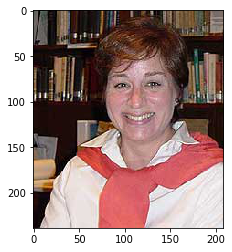

In [3]:
# display the image
plt.imshow(img_np)
plt.show()

In [6]:
img_tensor=torch.from_numpy(img_np)
print(img_tensor.shape)

torch.Size([239, 209, 3])


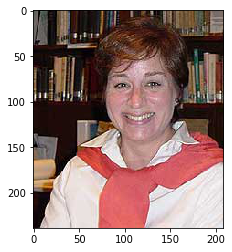

In [7]:
# display the image
plt.imshow(img_tensor)
plt.show()


In [8]:
out=img_tensor.permute(2,0,1)   # Pytorch: Channelxheightxwidth =CxHxW
print(out.shape)

torch.Size([3, 239, 209])


torch.Size([4, 3, 96, 96])


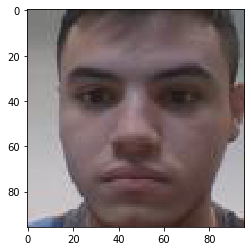

In [20]:
batch_size = 4
batch = torch.zeros(batch_size, 3, 96, 96, dtype=torch.uint8)
import os
data_dir = '../torch_tutorial/data/student_faces/'
filenames = [name for name in os.listdir(data_dir) if os.path.splitext(name)[-1] == '.jpg']
for i, filename in enumerate(filenames):
    img_arr = imageio.imread(os.path.join(data_dir, filename))
    img_t = torch.from_numpy(img_arr)
    img_t = img_t.permute(2, 0, 1)
    img_t = img_t[:3]
    batch[i] = img_t
    
print(batch.shape)
# display the image
plt.imshow(batch[1].permute(1,2,0))
plt.show()

In [22]:
import csv

In [23]:
import numpy as np

In [24]:
xy_path = "c:/machine_learning/mnist_test.csv"
xy_numpy = np.loadtxt(xy_path, delimiter=",")
xy_t=torch.tensor(xy_numpy)

In [25]:
print(xy_t.shape)
xy_t

torch.Size([10000, 785])


tensor([[7., 0., 0.,  ..., 0., 0., 0.],
        [2., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [4., 0., 0.,  ..., 0., 0., 0.],
        [5., 0., 0.,  ..., 0., 0., 0.],
        [6., 0., 0.,  ..., 0., 0., 0.]], dtype=torch.float64)

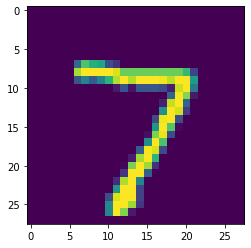

In [26]:
# display the image
plt.imshow(xy_t[0][1:].view(28,28))
plt.show()

In [27]:
wine_path = "../torch_tutorial/data/winequality-white.csv"
wine_numpy = np.loadtxt(wine_path, delimiter=";", skiprows=1)
wine_tensor=torch.from_numpy(wine_numpy)
print(wine_tensor.shape)
wine_tensor


torch.Size([4898, 12])


tensor([[ 7.0000,  0.2700,  0.3600,  ...,  0.4500,  8.8000,  6.0000],
        [ 6.3000,  0.3000,  0.3400,  ...,  0.4900,  9.5000,  6.0000],
        [ 8.1000,  0.2800,  0.4000,  ...,  0.4400, 10.1000,  6.0000],
        ...,
        [ 6.5000,  0.2400,  0.1900,  ...,  0.4600,  9.4000,  6.0000],
        [ 5.5000,  0.2900,  0.3000,  ...,  0.3800, 12.8000,  7.0000],
        [ 6.0000,  0.2100,  0.3800,  ...,  0.3200, 11.8000,  6.0000]],
       dtype=torch.float64)

In [28]:
col_list =next(csv.reader(open(wine_path), delimiter=';'))

col_list


['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

In [29]:
# split the data into input and label
input_data=wine_tensor[:,:-1]
label=wine_tensor[:, -1].long()
print(label)


tensor([6, 6, 6,  ..., 6, 7, 6])


In [30]:
# normalize each feature
input_data_mean=torch.mean(input_data, 0)
input_data_var=torch.var(input_data,0)
input_data_normalized = (input_data - input_data_mean) / torch.sqrt(input_data_var)


In [31]:
# generate onehot for label tensor
label_examples=torch.tensor([0,1,2,3,4,5,6,7,8,9,3,4,9,1])
label_onehot = torch.zeros(label_examples.shape[0], 10)
label_onehot.scatter_(1, label_examples.unsqueeze(1), 1.0)
label_onehot

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [32]:
y = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
x = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

# training dataset

In [14]:
x=torch.tensor([6.1101, 5.5277, 8.5186, 7.0032, 5.8598, 8.3829, 7.4764, 8.5781, 6.4862, 5.0546, 5.7107, 14.164, 5.734, 8.4084, 5.6407, 5.3794, 6.3654, 5.1301, 6.4296, 7.0708])

In [15]:
y=torch.tensor([17.592, 9.1302, 13.662, 11.854, 6.8233, 11.886, 4.3483, 12, 6.5987, 3.8166,3.2522, 15.505, 3.1551, 7.2258, 0.71618, 3.5129, 5.3048, 0.56077, 3.6518, 5.3893]) 

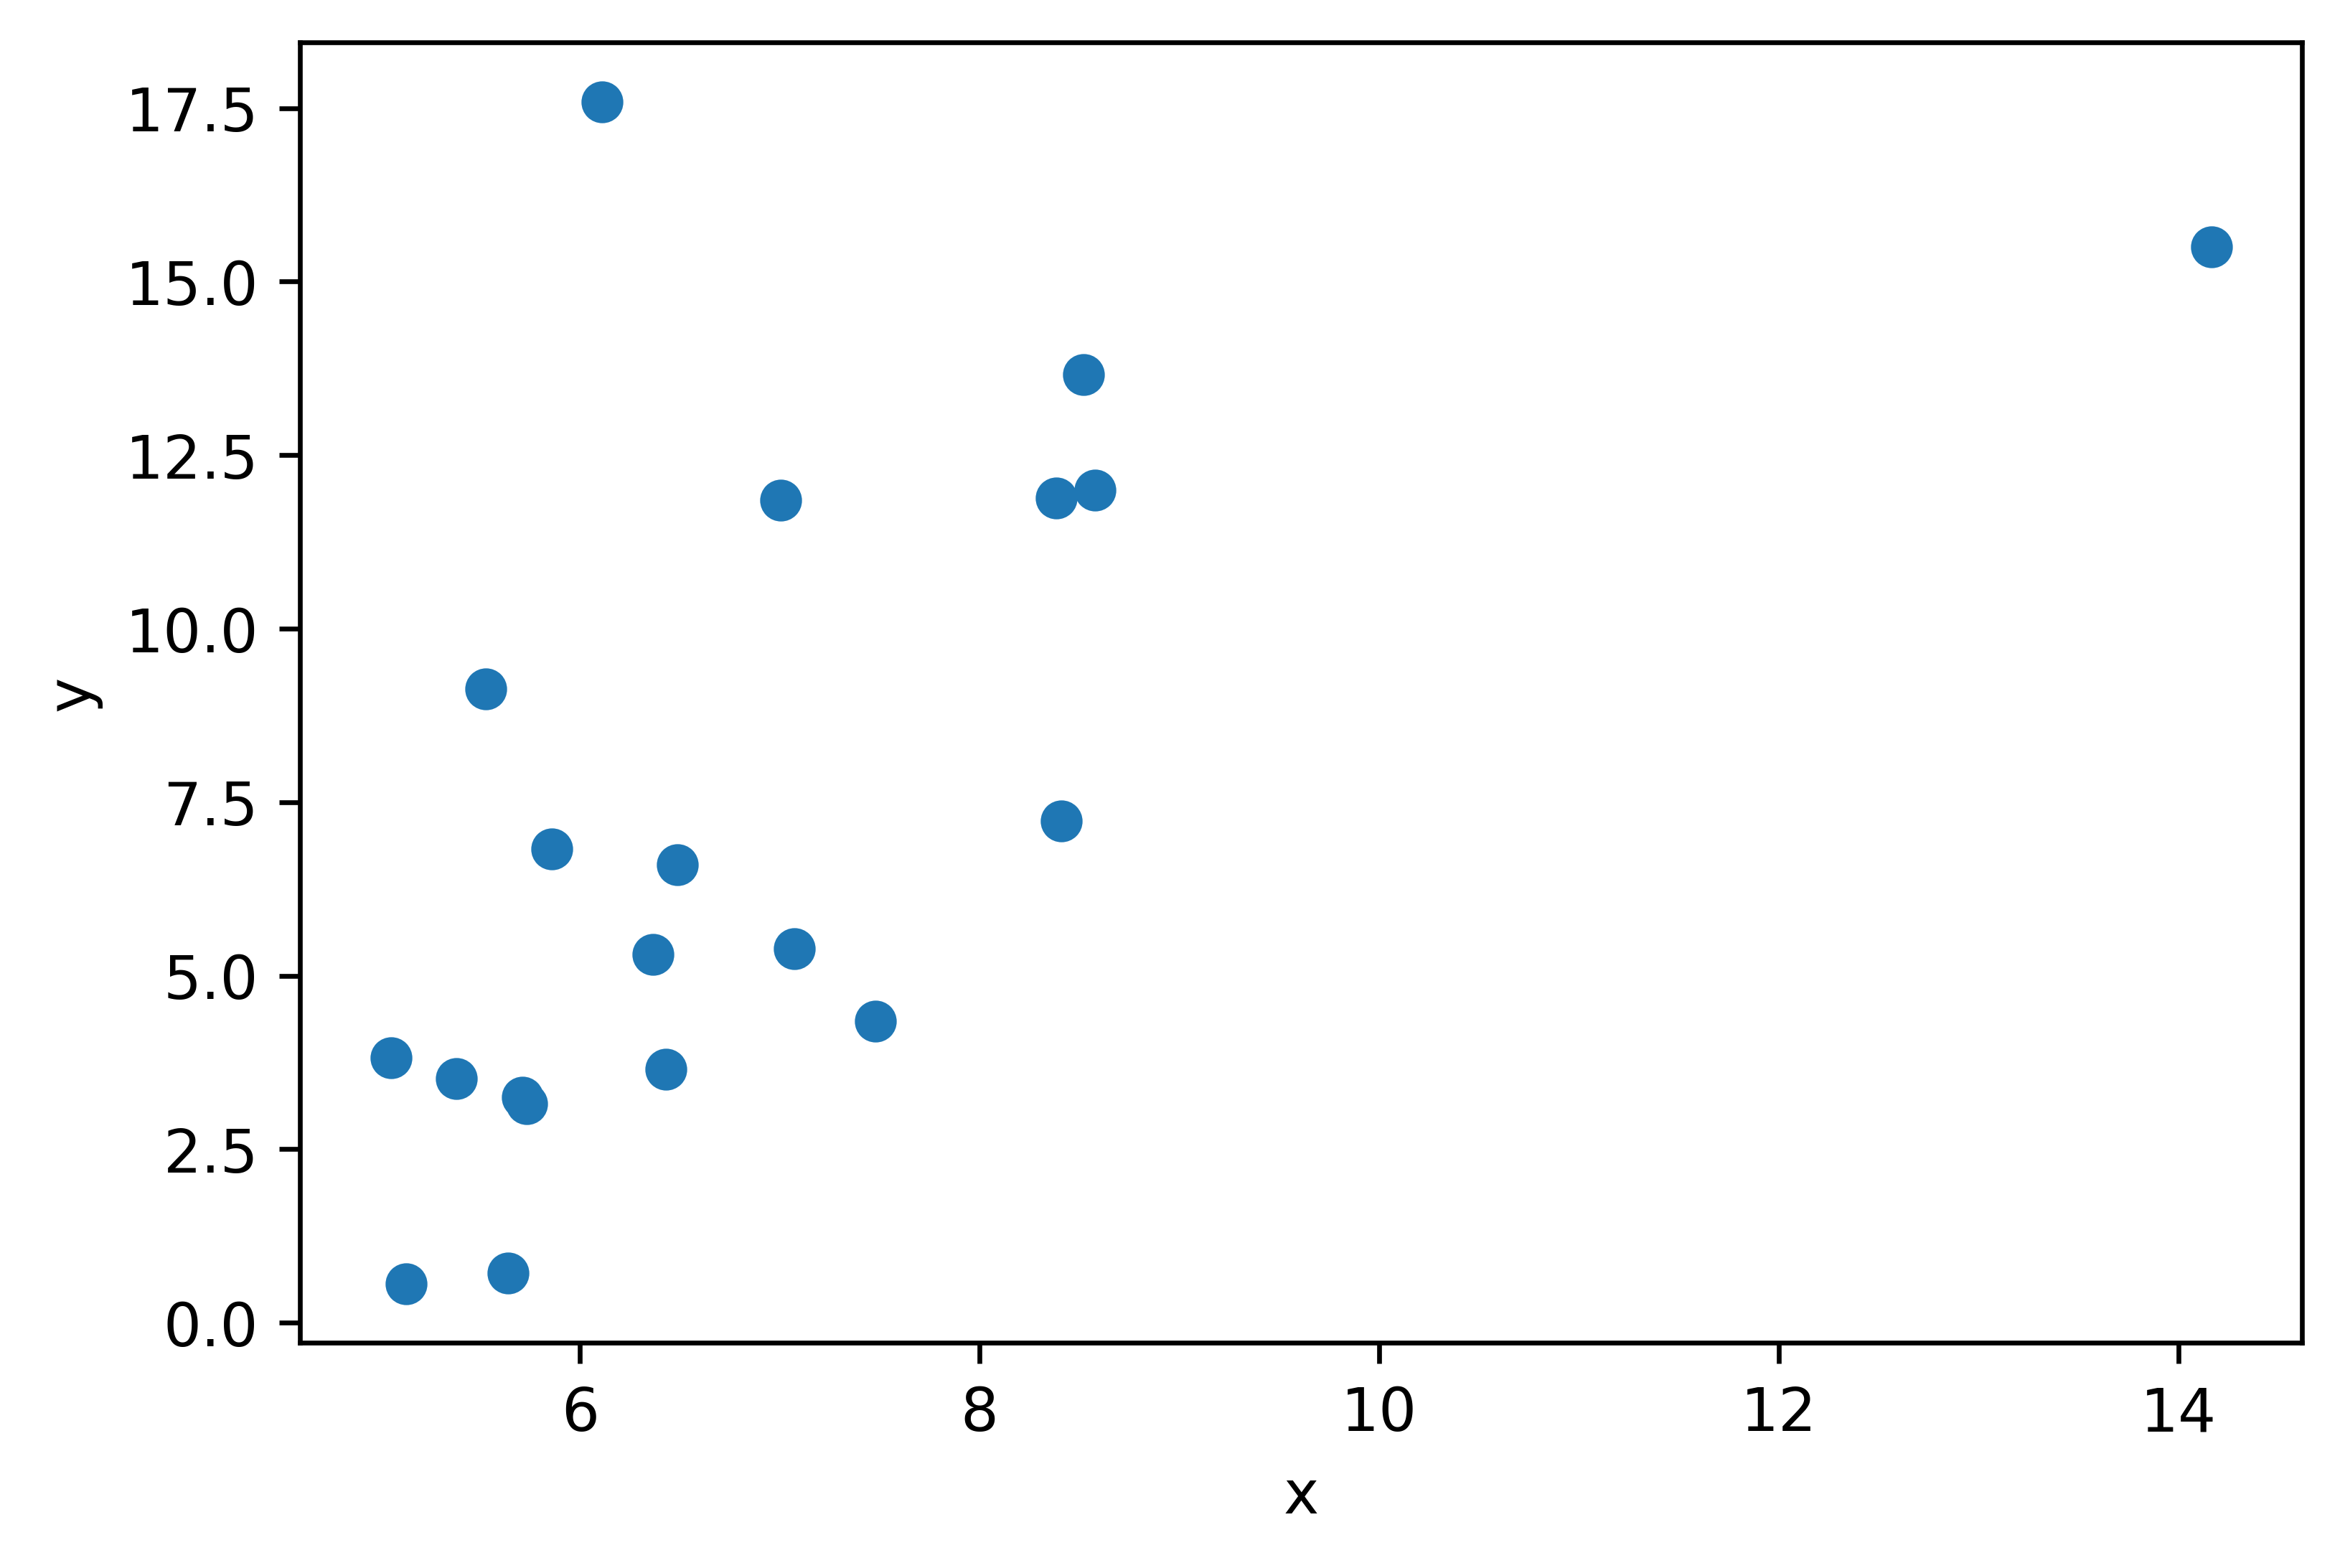

In [16]:
from matplotlib import pyplot as plt
fig = plt.figure(dpi=600)
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), y.numpy(), 'o')
plt.show()

In [17]:
# 1) define the linear model
def model_linear(x,w,b):
    y=w*x+b
    return y

In [18]:
# 2) define the loss function
def loss_fn(y, label):
    se=(y-label)**2
    mse=se.mean()
    return mse

In [45]:
# 3) define the gradient
def grad_fn(x,y,w,b):
    y_pred=model_linear(x,w,b)
    dw=2.0*(y_pred-y)*x/y.size(0)
    db=2.0*(y_pred-y)/y.size(0)
    return torch.stack([dw.sum(),db.sum()])


In [46]:
# 4) define the training loop
def training_loop(n_epochs, learning_rate, params, x, y):
    loss_tensor=torch.zeros(n_epochs)
    for epoch in range(1, n_epochs+1):
        w,b=params
        y_pred=model_linear(x,w,b)
        loss=loss_fn(y_pred,y)
        grad=grad_fn(x,y,w,b)
        params=params-learning_rate*grad
        print('Epoch %d, Loss %f' % (epoch, float(loss))) 
        loss_tensor[epoch-1]=loss
    return params, loss_tensor

In [47]:
params, loss_tensor= training_loop(
    n_epochs = 100,
    learning_rate = 0.002,
    params =torch.tensor([0.0,0.0]),
    x=x,
    y=y) 


Epoch 1, Loss 76.284782
Epoch 2, Loss 52.976959
Epoch 3, Loss 38.543888
Epoch 4, Loss 29.606319
Epoch 5, Loss 24.071735
Epoch 6, Loss 20.644384
Epoch 7, Loss 18.521904
Epoch 8, Loss 17.207441
Epoch 9, Loss 16.393320
Epoch 10, Loss 15.889035
Epoch 11, Loss 15.576597
Epoch 12, Loss 15.382973
Epoch 13, Loss 15.262909
Epoch 14, Loss 15.188403
Epoch 15, Loss 15.142103
Epoch 16, Loss 15.113276
Epoch 17, Loss 15.095263
Epoch 18, Loss 15.083949
Epoch 19, Loss 15.076782
Epoch 20, Loss 15.072186
Epoch 21, Loss 15.069178
Epoch 22, Loss 15.067160
Epoch 23, Loss 15.065744
Epoch 24, Loss 15.064711
Epoch 25, Loss 15.063910
Epoch 26, Loss 15.063258
Epoch 27, Loss 15.062693
Epoch 28, Loss 15.062184
Epoch 29, Loss 15.061707
Epoch 30, Loss 15.061255
Epoch 31, Loss 15.060816
Epoch 32, Loss 15.060385
Epoch 33, Loss 15.059961
Epoch 34, Loss 15.059538
Epoch 35, Loss 15.059117
Epoch 36, Loss 15.058699
Epoch 37, Loss 15.058281
Epoch 38, Loss 15.057864
Epoch 39, Loss 15.057446
Epoch 40, Loss 15.057033
Epoch 41,

In [48]:
params

tensor([1.0746, 0.0512])

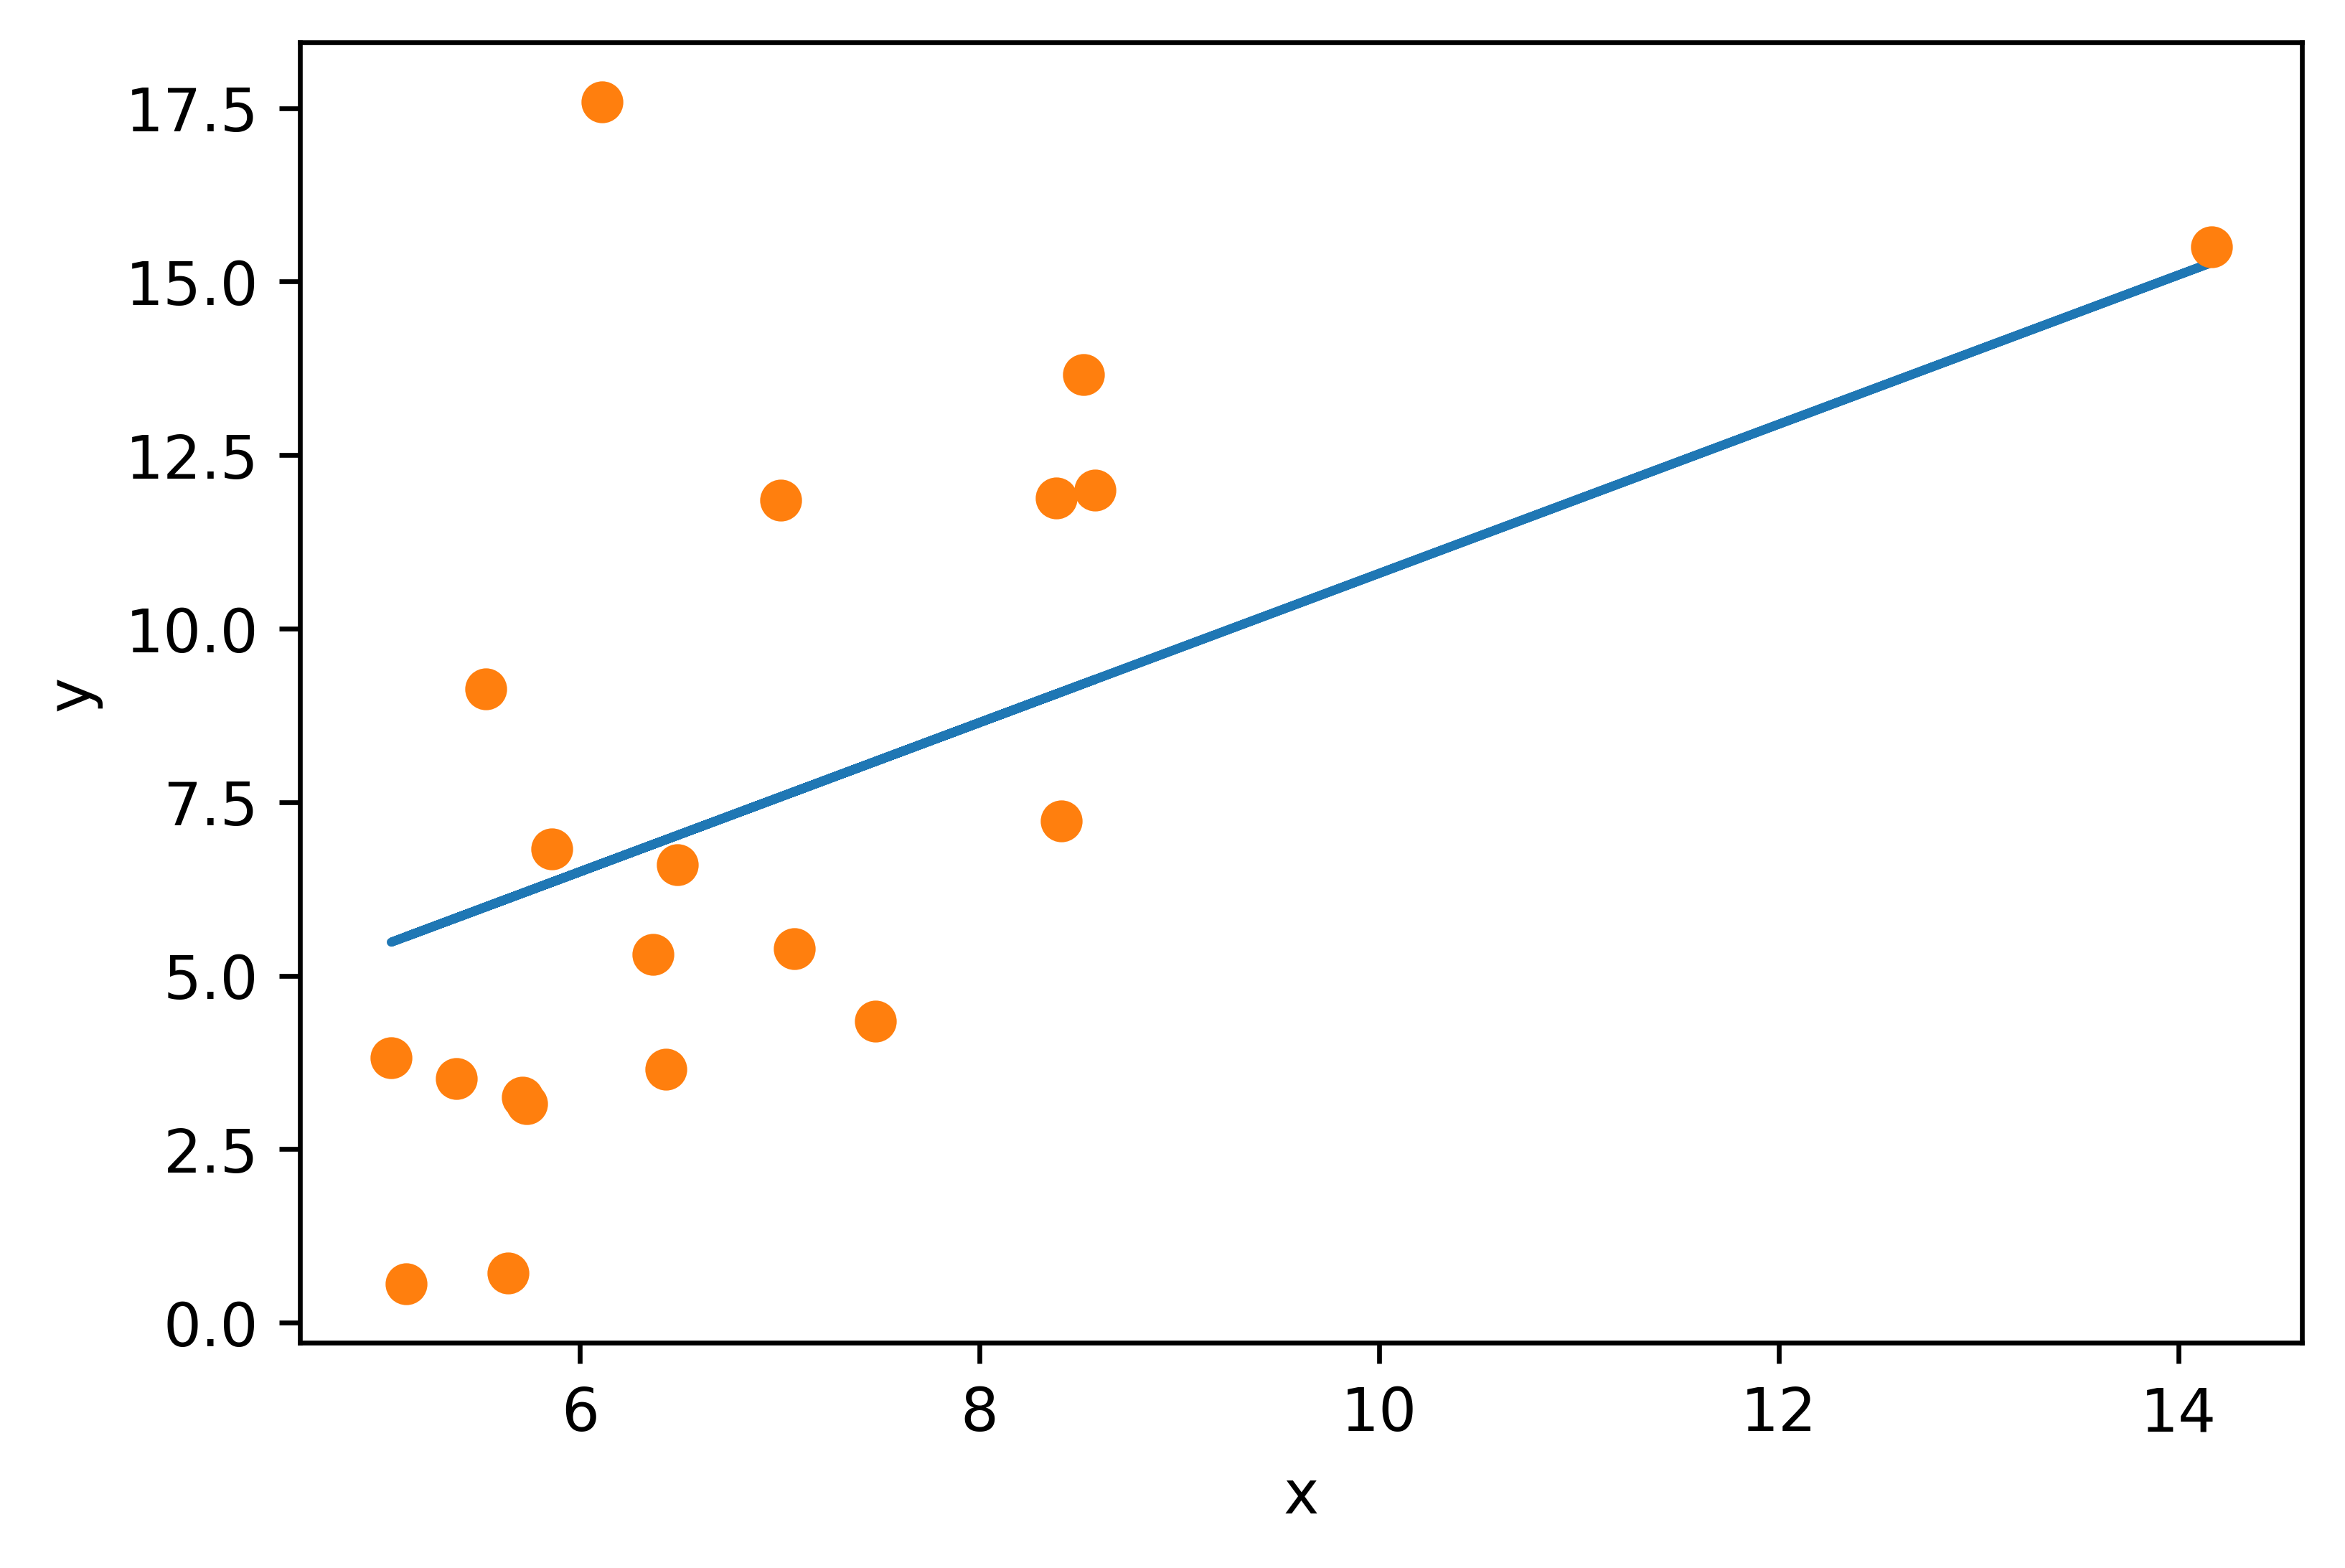

In [49]:
fig = plt.figure(dpi=600)
pred=model_linear(x,params[0],params[1])
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), pred.detach().numpy())
plt.plot(x.numpy(), y.numpy(), 'o')

In [50]:
pred.shape

torch.Size([20])

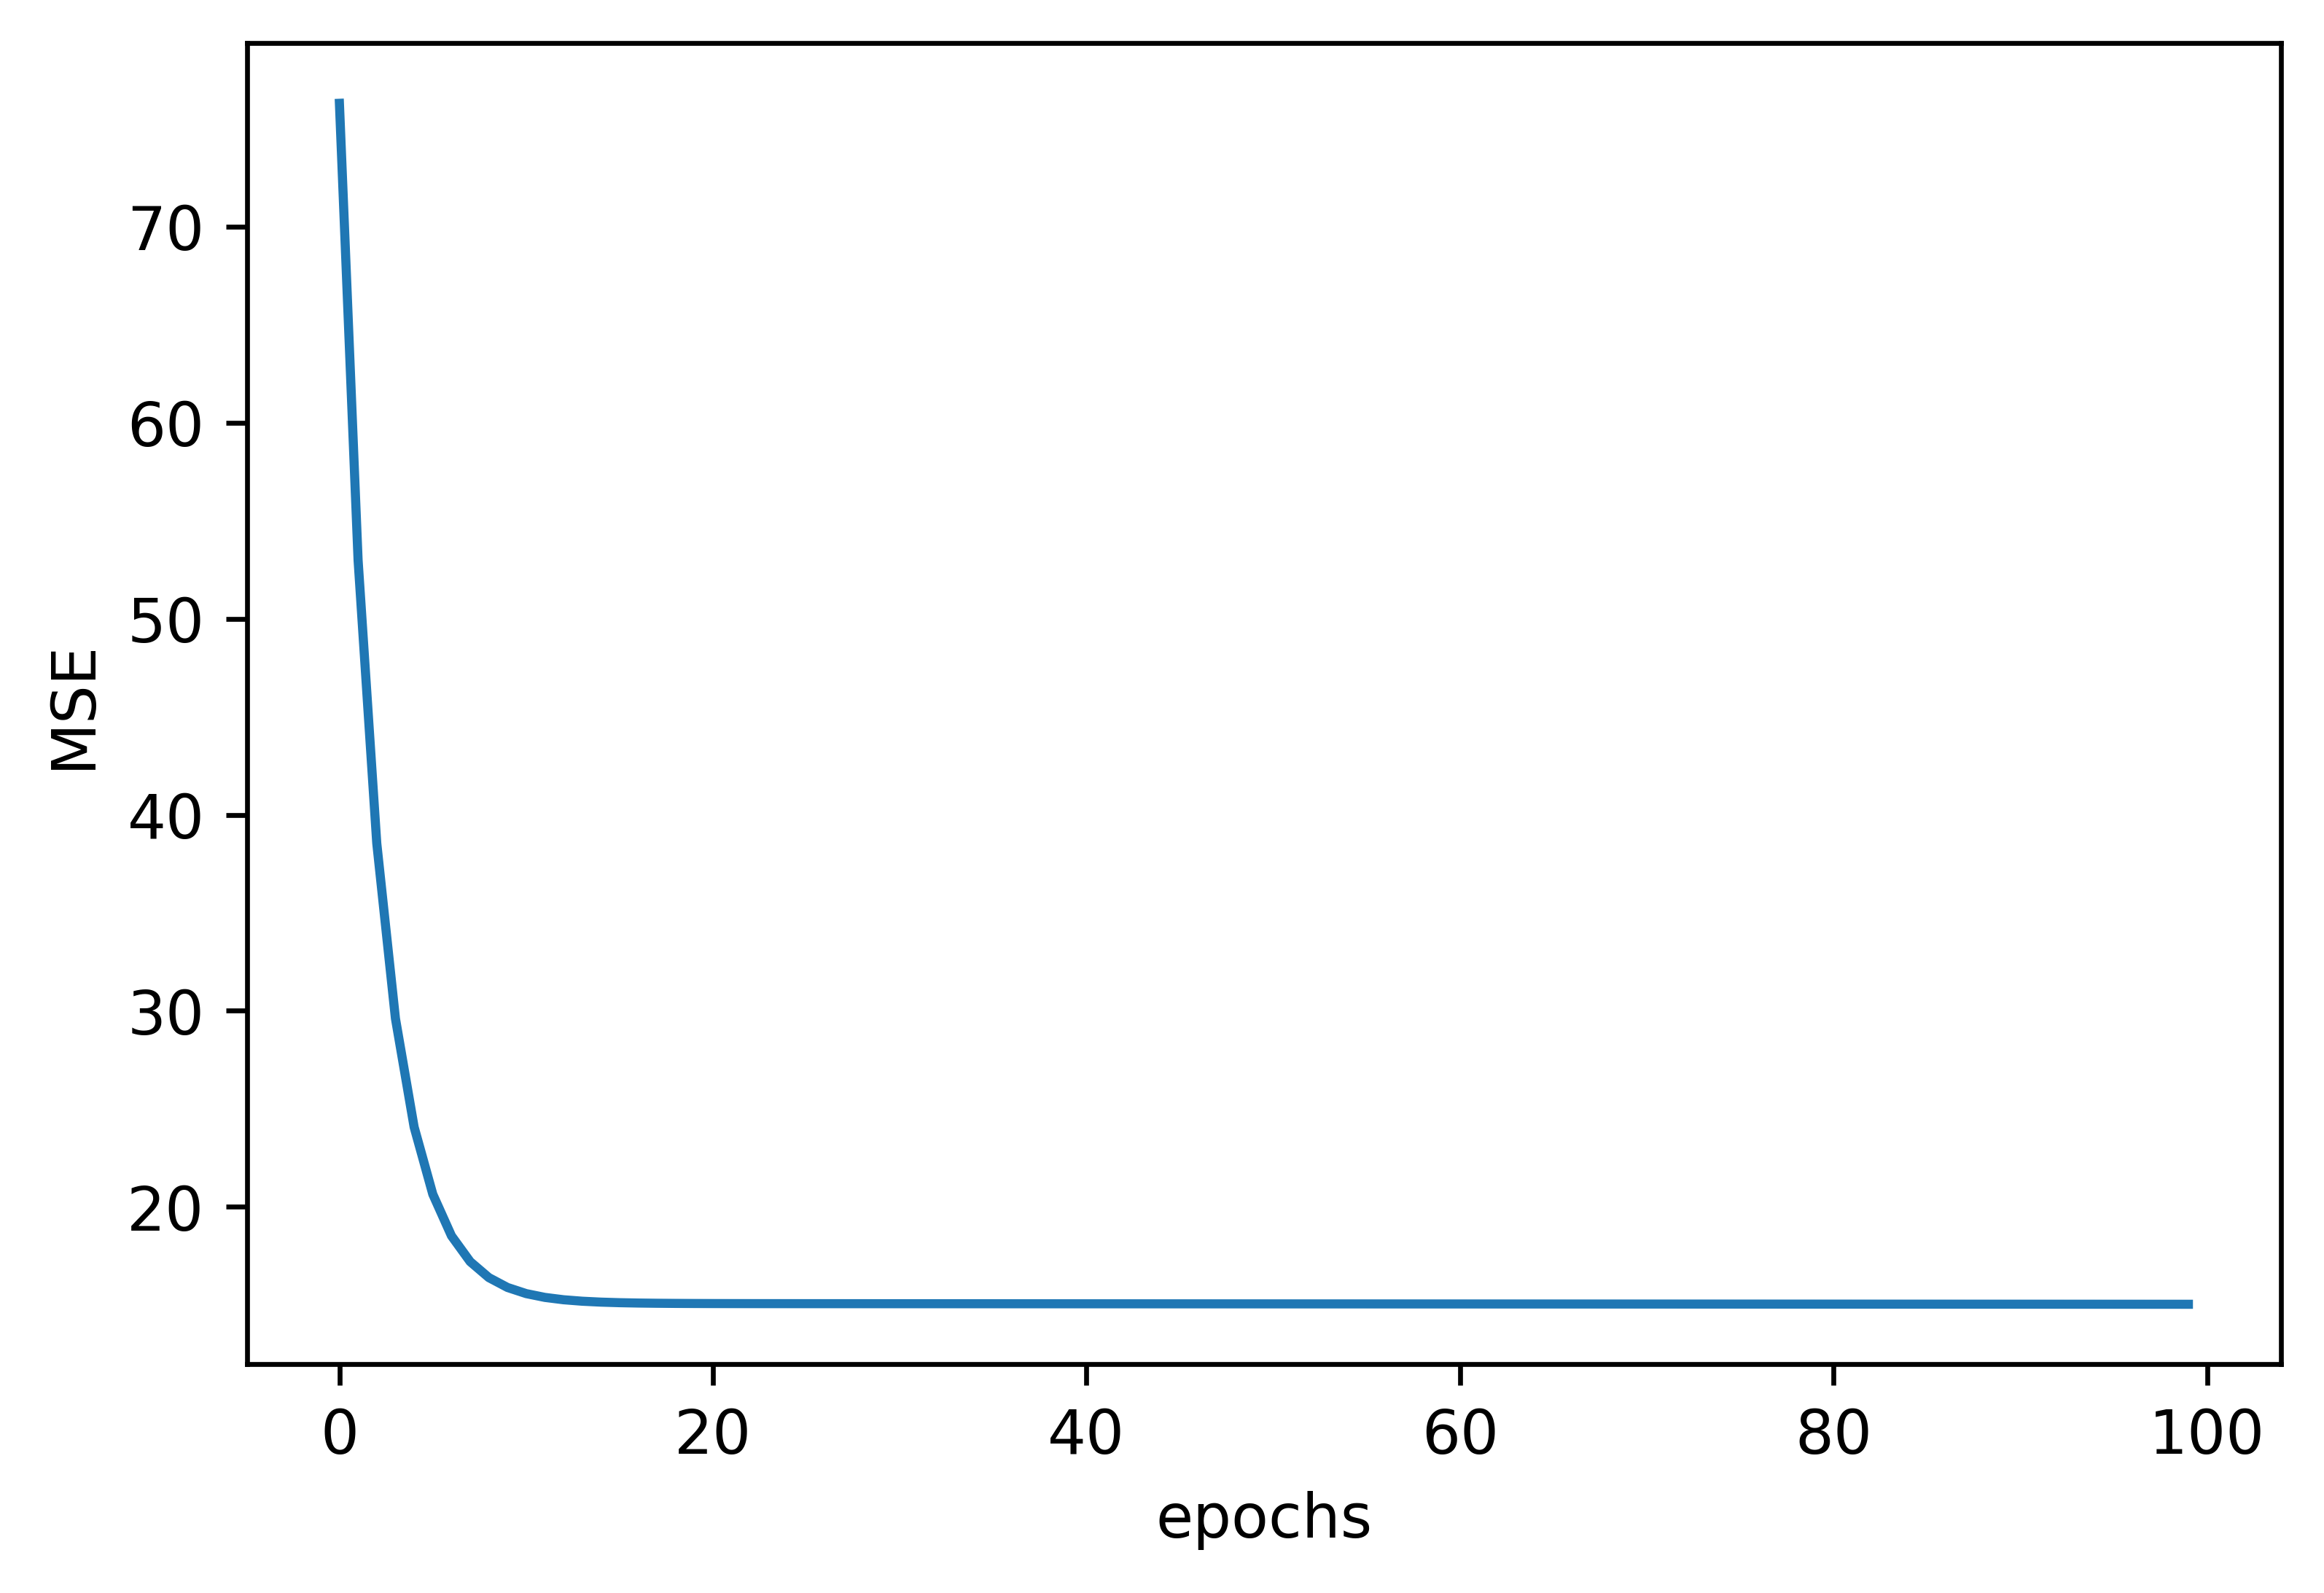

In [51]:
fig = plt.figure(dpi=600)
plt.xlabel("epochs")
plt.ylabel("MSE")
plt.plot(loss_tensor.detach().numpy())

In [52]:
#params.grad.zero_()
params.grad is None
#params.grad

True

comments: using autograd, don't need to derive the gradient equation

In [27]:
params = torch.tensor([1.0, 0.0], requires_grad=True)


In [28]:
y_pred=model_linear(x,params[0], params[1])           #forward propagation

In [29]:
loss=loss_fn(y_pred,y)           #loss computation

In [30]:
loss.backward()           # call .backward() for autograd

In [31]:
params.grad # dlss/dw, dloss/db

tensor([-8.5768, -0.6954])

In [32]:
y_pred=model_linear(x,params[0], params[1])           #forward propagation
loss=loss_fn(y_pred,y)           #loss computation
loss.backward()           # call .backward() for autograd
params.grad             # display gradient values


tensor([-17.1536,  -1.3908])

In [33]:
if params.grad is not None:
    params.grad.zero_()

In [34]:
params

tensor([1., 0.], requires_grad=True)

In [35]:
params.grad

tensor([0., 0.])

In [36]:
y_pred=model_linear(x,params[0], params[1])           #forward propagation
loss=loss_fn(y_pred,y)           #loss computation
loss.backward()           # call .backward() for autograd
params.grad             # display gradient values


tensor([-8.5768, -0.6954])

In [37]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
def training_loop_autograd(n_epochs, learning_rate, params, x, y):
    loss_tensor=torch.zeros(n_epochs)
    for epoch in range(1, n_epochs+1):
        if params.grad is not None:
            params.grad.zero_()
        w,b=params
        y_pred=model_linear(x,w,b)
        loss=loss_fn(y_pred,y)
        loss.backward()
        
        with torch.no_grad():                        # no grad computation involved
            params -= learning_rate * params.grad
        
        #params=params-learning_rate*grad
        print('Epoch %d, Loss %f' % (epoch, float(loss))) 
        loss_tensor[epoch-1]=loss
    return params, loss_tensor


In [38]:
params, loss_tensor= training_loop_autograd(
    n_epochs = 100,
    learning_rate = 0.002,
    params =torch.tensor([0.0,0.0], requires_grad=True),
    x=x,
    y=y)


Epoch 1, Loss 76.284782
Epoch 2, Loss 52.976959
Epoch 3, Loss 38.543884
Epoch 4, Loss 29.606318
Epoch 5, Loss 24.071735
Epoch 6, Loss 20.644382
Epoch 7, Loss 18.521906
Epoch 8, Loss 17.207439
Epoch 9, Loss 16.393318
Epoch 10, Loss 15.889033
Epoch 11, Loss 15.576597
Epoch 12, Loss 15.382970
Epoch 13, Loss 15.262909
Epoch 14, Loss 15.188403
Epoch 15, Loss 15.142103
Epoch 16, Loss 15.113276
Epoch 17, Loss 15.095263
Epoch 18, Loss 15.083949
Epoch 19, Loss 15.076782
Epoch 20, Loss 15.072186
Epoch 21, Loss 15.069178
Epoch 22, Loss 15.067160
Epoch 23, Loss 15.065744
Epoch 24, Loss 15.064711
Epoch 25, Loss 15.063910
Epoch 26, Loss 15.063258
Epoch 27, Loss 15.062693
Epoch 28, Loss 15.062184
Epoch 29, Loss 15.061707
Epoch 30, Loss 15.061255
Epoch 31, Loss 15.060816
Epoch 32, Loss 15.060385
Epoch 33, Loss 15.059961
Epoch 34, Loss 15.059538
Epoch 35, Loss 15.059117
Epoch 36, Loss 15.058699
Epoch 37, Loss 15.058281
Epoch 38, Loss 15.057864
Epoch 39, Loss 15.057446
Epoch 40, Loss 15.057033
Epoch 41,

In [39]:
params

tensor([1.0746, 0.0512], requires_grad=True)

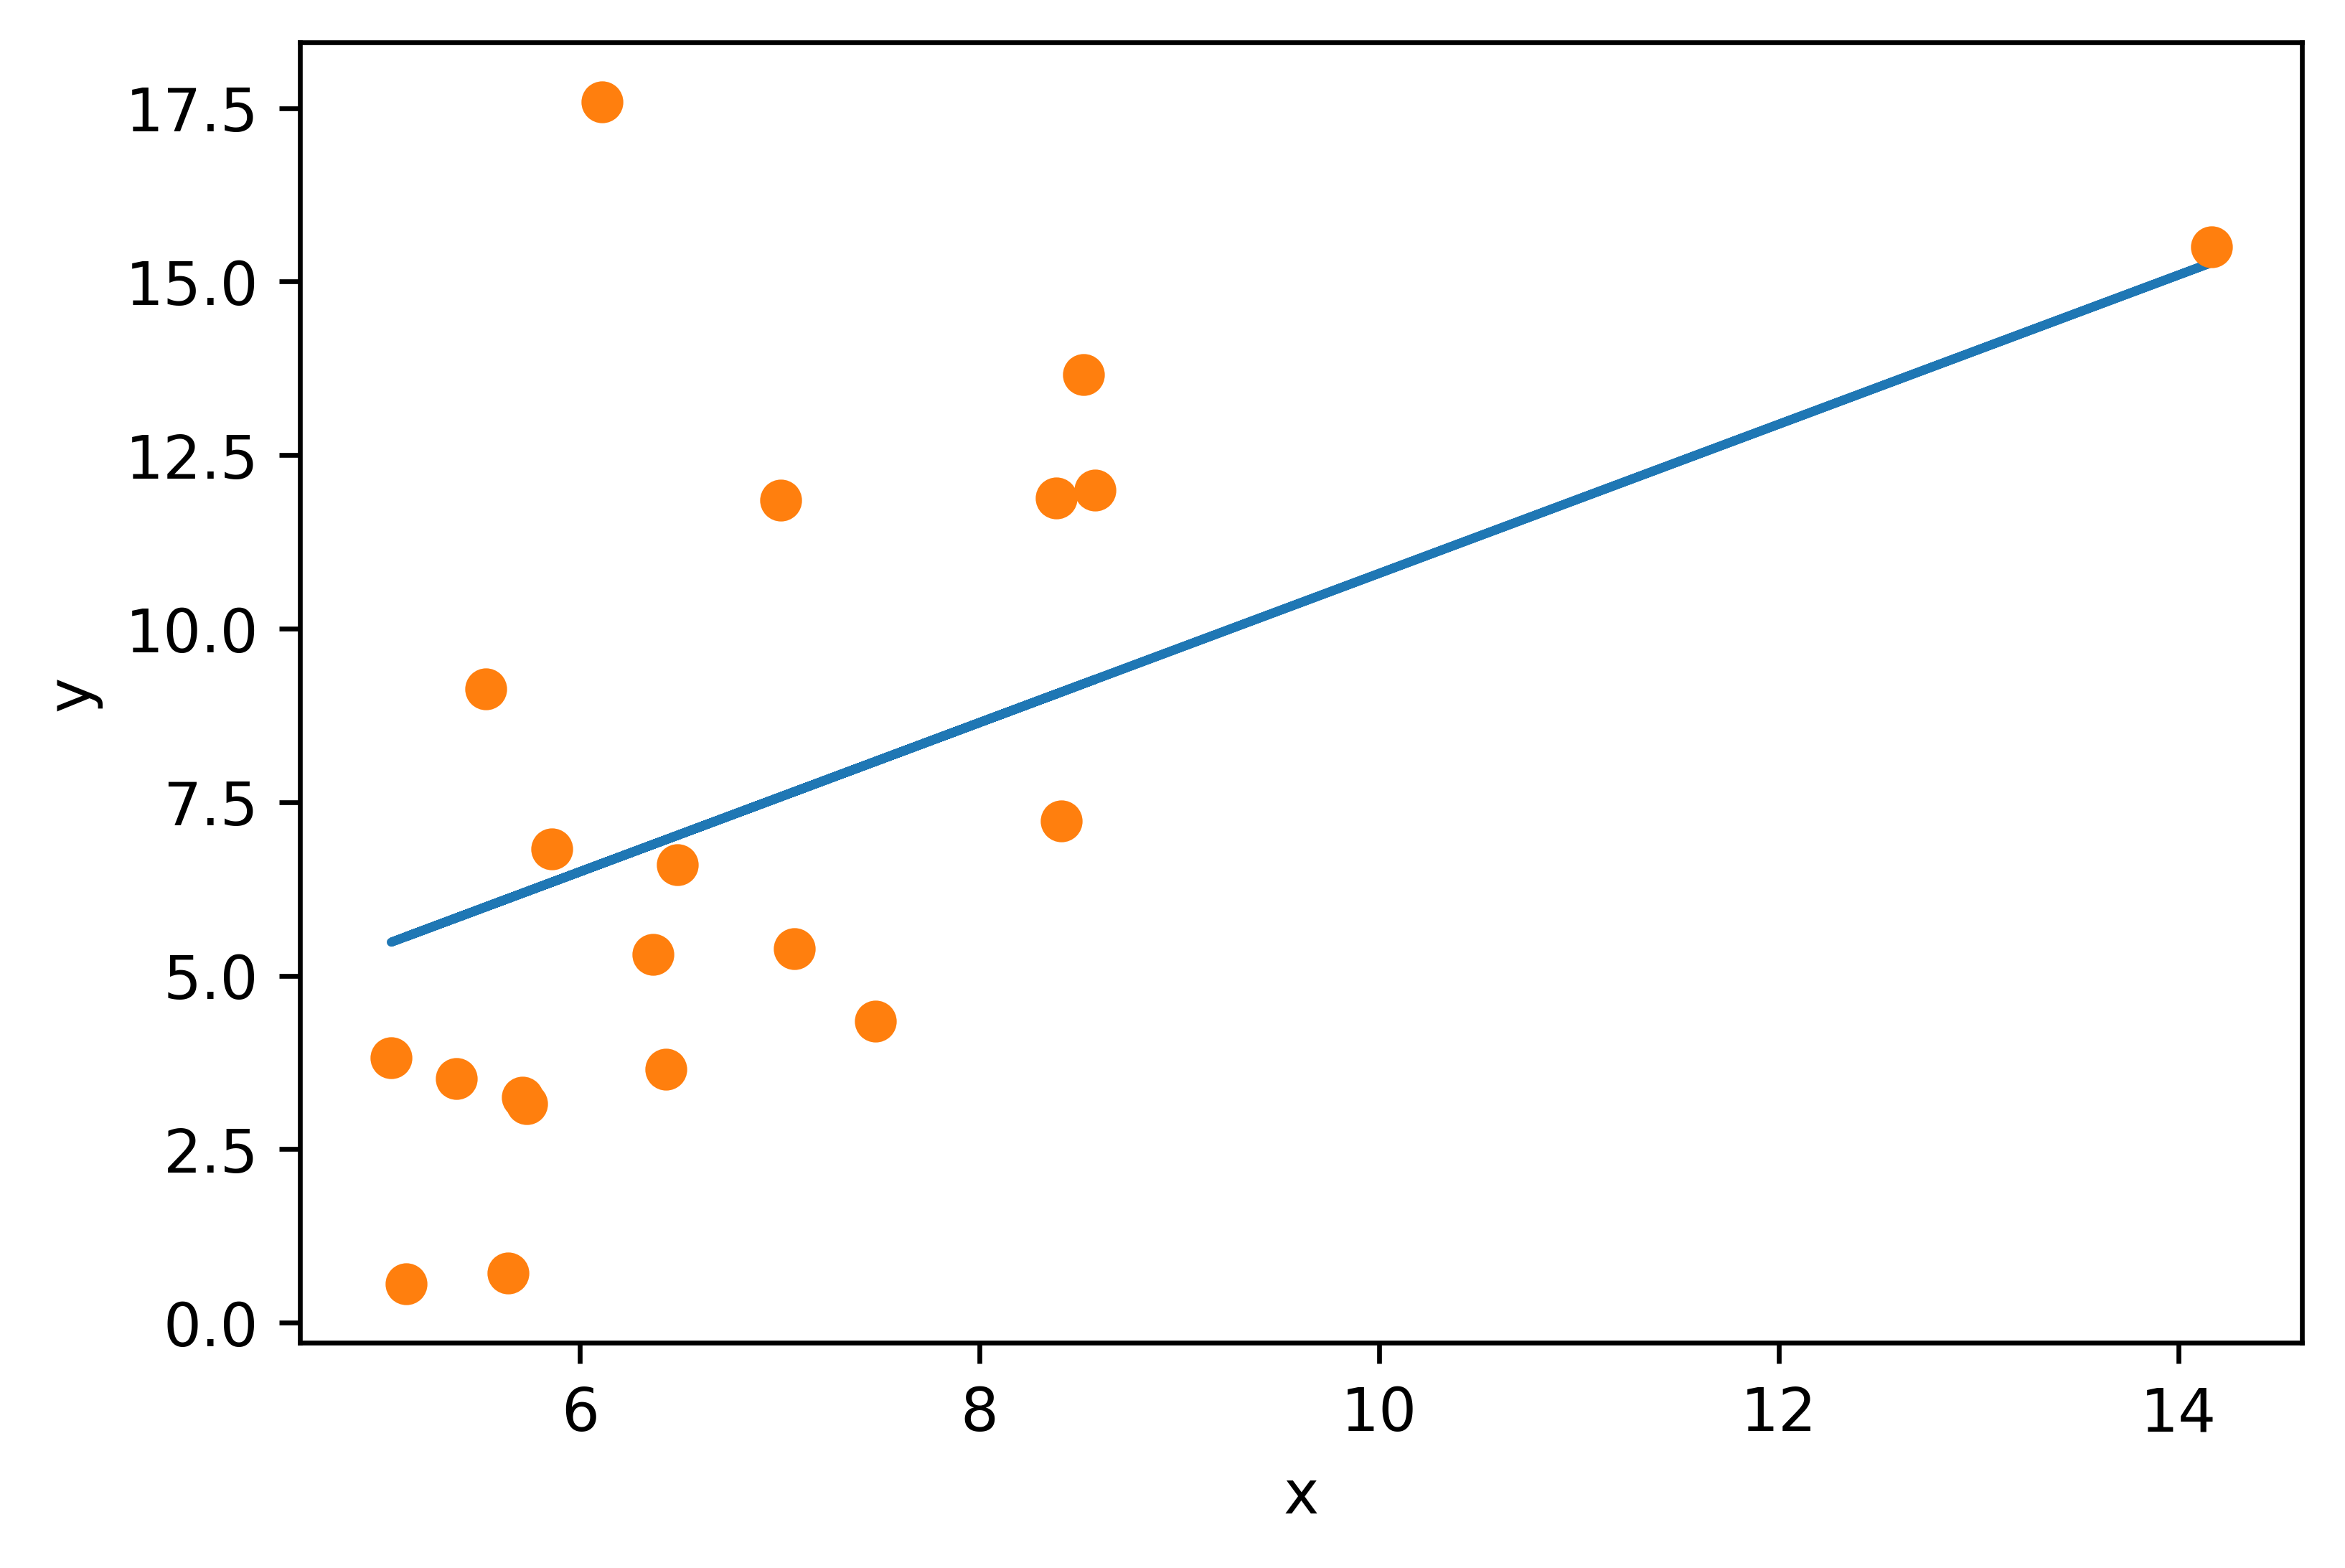

In [30]:
fig = plt.figure(dpi=600)
pred=model_linear(x,params[0],params[1])
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), pred.detach().numpy())
plt.plot(x.numpy(), y.numpy(), 'o')

In [33]:
import torch.optim as optim
dir(optim)

['ASGD',
 'Adadelta',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Optimizer',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'lr_scheduler']

In [40]:
params = torch.tensor([0.0,0.0], requires_grad=True)
learning_rate=0.002
my_optimizer = optim.SGD([params], lr=learning_rate)   # construct an optimizer 
y_pred=model_linear(x,params[0], params[1])           #forward propagation
loss=loss_fn(y_pred,y)           #loss computation
my_optimizer.zero_grad()    # zero grad
loss.backward()           # call .backward() for autograd
my_optimizer.step()     # one step params update
params.grad             # display gradient values

tensor([-113.2717,  -14.5985])

In [41]:
params

tensor([0.2265, 0.0292], requires_grad=True)

In [42]:
#params = torch.tensor([0.0,0.0], requires_grad=True)
def training_loop_autograd_optim(optimizer, n_epochs, params, x, y):
    loss_tensor=torch.zeros(n_epochs)
    for epoch in range(1, n_epochs+1):
        w,b=params                  # forward path
        y_pred=model_linear(x,w,b)
        loss=loss_fn(y_pred,y)      # loss
        optimizer.zero_grad()       # zero grad
        loss.backward()             # calculate grad by autograd
        optimizer.step()            # update params by optimizer
         
        print('Epoch %d, Loss %f' % (epoch, float(loss))) 
        loss_tensor[epoch-1]=loss
    return params, loss_tensor


In [43]:
params = torch.tensor([0.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.RMSprop([params], lr=learning_rate)
params, loss_tensor = training_loop_autograd_optim(
n_epochs = 100,
optimizer = optimizer,
params = params,
x = x,
y = y)

Epoch 1, Loss 76.284782
Epoch 2, Loss 64.170250
Epoch 3, Loss 56.819836
Epoch 4, Loss 51.455879
Epoch 5, Loss 47.234806
Epoch 6, Loss 43.772202
Epoch 7, Loss 40.855797
Epoch 8, Loss 38.354164
Epoch 9, Loss 36.179409
Epoch 10, Loss 34.269463
Epoch 11, Loss 32.578590
Epoch 12, Loss 31.072016
Epoch 13, Loss 29.722561
Epoch 14, Loss 28.508566
Epoch 15, Loss 27.412430
Epoch 16, Loss 26.419617
Epoch 17, Loss 25.518032
Epoch 18, Loss 24.697428
Epoch 19, Loss 23.949059
Epoch 20, Loss 23.265417
Epoch 21, Loss 22.639984
Epoch 22, Loss 22.067076
Epoch 23, Loss 21.541700
Epoch 24, Loss 21.059450
Epoch 25, Loss 20.616413
Epoch 26, Loss 20.209105
Epoch 27, Loss 19.834415
Epoch 28, Loss 19.489548
Epoch 29, Loss 19.171986
Epoch 30, Loss 18.879444
Epoch 31, Loss 18.609877
Epoch 32, Loss 18.361408
Epoch 33, Loss 18.132341
Epoch 34, Loss 17.921125
Epoch 35, Loss 17.726349
Epoch 36, Loss 17.546713
Epoch 37, Loss 17.381031
Epoch 38, Loss 17.228222
Epoch 39, Loss 17.087280
Epoch 40, Loss 16.957302
Epoch 41,

In [44]:
params

tensor([0.9578, 0.8307], requires_grad=True)

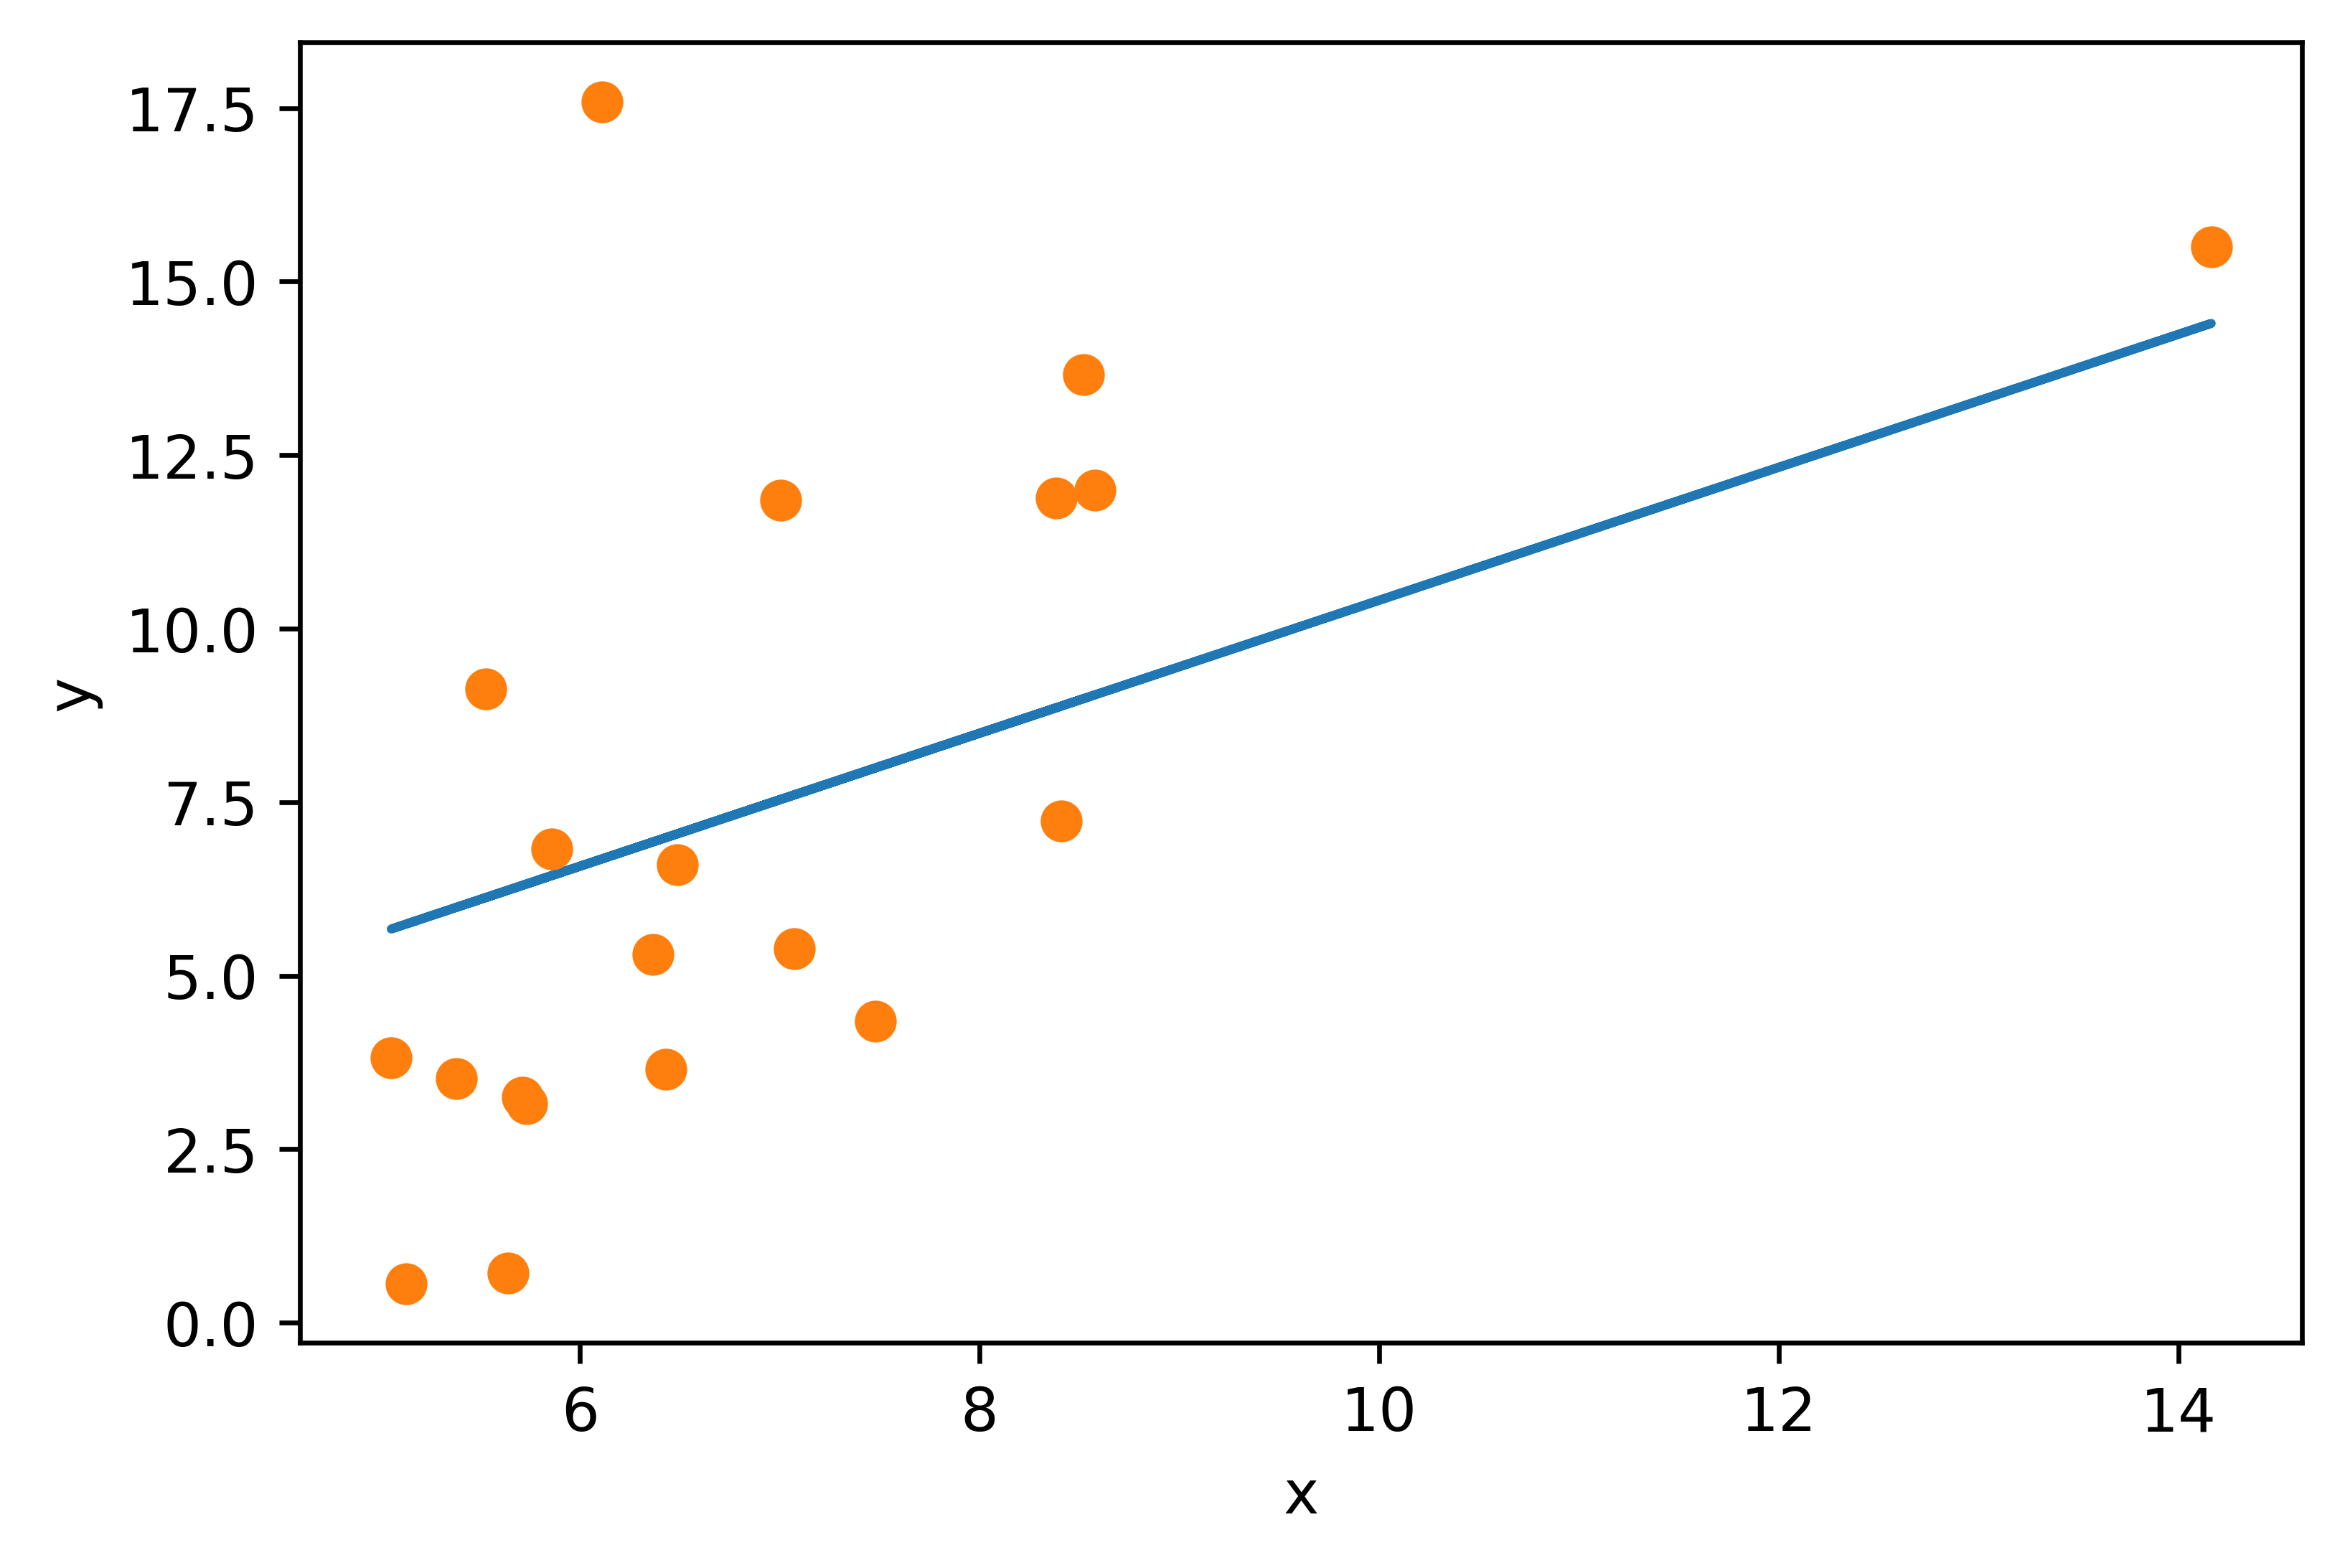

In [45]:
fig = plt.figure(dpi=600)
pred=model_linear(x,params[0],params[1])
plt.xlabel("x")
plt.ylabel("y")
plt.plot(x.numpy(), pred.detach().numpy())
plt.plot(x.numpy(), y.numpy(), 'o')

In [119]:
print(torch.__version__)

1.4.0


In [46]:
from torchvision import datasets
'''
CLASStorchvision.datasets.CIFAR10(root, train=True, transform=None, target_transform=None, download=False) 

--root (string) – Root directory of dataset where directory 
  cifar-10-batches-py exists or will be saved to if download 
  is set to True.
--train (bool, optional) – If True, creates dataset from training set, 
  otherwise creates from test set.
--transform (callable, optional) – A function/transform that takes 
  in an PIL image and returns a transformed version. E.g, transforms.RandomCrop
--target_transform (callable, optional) – A function/transform that 
  takes in the target and transforms it.
--download (bool, optional) – If true, downloads the dataset from the internet 
  and puts it in root directory.If dataset is already downloaded, 
  it is not downloaded again.

Return
(image, target) where target is index of the target class.

'''
data_path = './data'
cifar10 = datasets.CIFAR10(data_path, train=True, download=True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=True)


Files already downloaded and verified
Files already downloaded and verified


In [47]:
print("training set:", len(cifar10))
print("validation set:", len(cifar10_val))

training set: 50000
validation set: 10000


In [48]:
img, label = cifar10[5]
img, label

(<PIL.Image.Image image mode=RGB size=32x32 at 0x23153634748>, 1)

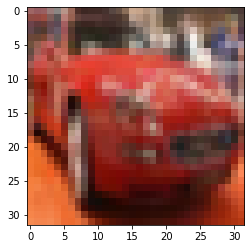

In [49]:
plt.imshow(img)
plt.show()

In [124]:
from torchvision import transforms
dir(transforms)

['CenterCrop',
 'ColorJitter',
 'Compose',
 'FiveCrop',
 'Grayscale',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'Pad',
 'RandomAffine',
 'RandomApply',
 'RandomChoice',
 'RandomCrop',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomOrder',
 'RandomPerspective',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSizedCrop',
 'RandomVerticalFlip',
 'Resize',
 'Scale',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'functional',
 'transforms']

In [53]:
from torchvision import transforms
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape

torch.Size([3, 32, 32])

In [54]:
img_t

tensor([[[0.6235, 0.5882, 0.6000,  ..., 0.3569, 0.2902, 0.2980],
         [0.5569, 0.5725, 0.6078,  ..., 0.4980, 0.4784, 0.3373],
         [0.4275, 0.3882, 0.4118,  ..., 0.5373, 0.6392, 0.3647],
         ...,
         [0.9569, 0.9412, 0.9451,  ..., 0.6118, 0.7020, 0.7843],
         [0.9647, 0.9529, 0.9529,  ..., 0.6353, 0.6980, 0.7529],
         [0.9647, 0.9529, 0.9569,  ..., 0.6510, 0.6784, 0.7137]],

        [[0.4000, 0.3569, 0.3725,  ..., 0.2784, 0.2471, 0.2275],
         [0.2941, 0.2824, 0.2980,  ..., 0.4118, 0.4353, 0.2706],
         [0.2627, 0.2275, 0.2314,  ..., 0.4392, 0.5176, 0.2824],
         ...,
         [0.5059, 0.4824, 0.4784,  ..., 0.1647, 0.2314, 0.2863],
         [0.5216, 0.5020, 0.4980,  ..., 0.1725, 0.2196, 0.2549],
         [0.5451, 0.5216, 0.5176,  ..., 0.1843, 0.2000, 0.2235]],

        [[0.3961, 0.3725, 0.3804,  ..., 0.2196, 0.2157, 0.2157],
         [0.2667, 0.2588, 0.2549,  ..., 0.2784, 0.3647, 0.2392],
         [0.2941, 0.2353, 0.2039,  ..., 0.3137, 0.4118, 0.

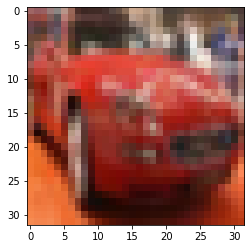

In [55]:
plt.imshow(img_t.permute(1, 2, 0))      # change dimension order to H,W,Channel
plt.show()

In [56]:
img_t[2][31][31]

tensor(0.0745)

In [57]:
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
transform=transforms.ToTensor())

In [58]:
img_t, label = tensor_cifar10[20]
img_t.shape, label

(torch.Size([3, 32, 32]), 4)

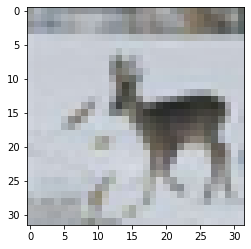

In [59]:
plt.imshow(img_t.permute(1, 2, 0))      # change dimension order to H,W,Channel
plt.show()

In [60]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
classes[label]

'deer'

In [61]:
norm_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
transform=transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5, 0.5, 0.5),(0.5,0.5,0.5))
]))

# transforms.Normalize(mean, std)

In [62]:
norm_img, label=norm_cifar10[5]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


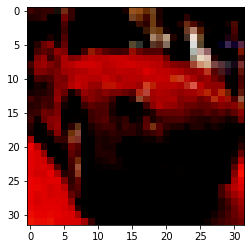

In [63]:
plt.imshow(norm_img.permute(1, 2, 0))      # change dimension order to H,W,Channel
plt.show()

In [64]:
norm_img.min()

tensor(-1.)

In [65]:
norm_img.max()

tensor(0.9765)

In [66]:
transform = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.5,0.5,0.5), (0.5, 0.5, 0.5))])

In [67]:
norm_cifar10 = datasets.CIFAR10(data_path, train=True, download=False,
transform=transform)

In [70]:
norm_img, label=norm_cifar10[5]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


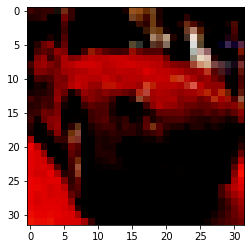

In [71]:
plt.imshow(norm_img.permute(1, 2, 0))      # change dimension order to H,W,Channel
plt.show()

In [72]:
norm_cifar10_test = datasets.CIFAR10(data_path, train=False, download=False,
transform=transform)

In [73]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label]) for img, label in norm_cifar10 if label in [0, 2]]
cifar2_test = [(img, label_map[label]) for img, label in norm_cifar10_test if label in [0, 2]]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


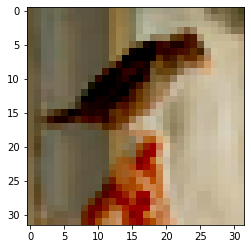

2000

In [74]:
norm_img, label=cifar2_test[31]
plt.imshow(norm_img.permute(1, 2, 0))      # change dimension order to H,W,Channel
plt.show()
len(cifar2_test)


In [144]:
len(cifar2_test)

2000

In [145]:
label

1

In [75]:
from torchvision import datasets
from torchvision import transforms
data_path = './data'
transform = transforms.Compose([transforms.ToTensor(),
              transforms.Normalize((0.5,0.5,0.5), (0.5, 0.5, 0.5))]) 

norm_cifar10 = datasets.CIFAR10(data_path, train=True, download=True,
transform=transform)
norm_cifar10_test = datasets.CIFAR10(data_path, train=False, download=True,
transform=transform)



Files already downloaded and verified
Files already downloaded and verified


In [76]:
len(norm_cifar10_test)

10000

In [77]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
norm_cifar2 = [(img, label_map[label]) for img, label in norm_cifar10 if label in [0, 2]]
norm_cifar2_test = [(img, label_map[label]) for img, label in norm_cifar10_test if label in [0, 2]]

In [81]:
len(norm_cifar2_test)

2000

In [79]:
birds=[(img, label) for img, label in norm_cifar2 if label in [1]]
airplanes=[(img, label) for img, label in norm_cifar2 if label in [0]]
print(len(birds), len(airplanes))

5000 5000


In [140]:
len(norm_cifar2)

10000

In [93]:
img, label=norm_cifar2[5]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


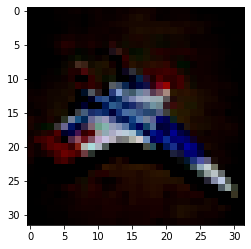

0


In [94]:
plt.imshow(img.permute(1, 2, 0))      # change dimension order to H,W,Channel
plt.show()
print(label)

In [95]:
img.shape

torch.Size([3, 32, 32])

In [135]:
import torch.nn as nn
n_out = 2
model = nn.Sequential(
    nn.Linear(3072,512,),
    nn.Tanh(),
    nn.Linear(512,n_out,),
    nn.LogSoftmax(dim=1)
    )

In [97]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


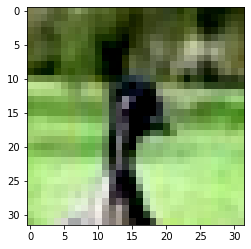

In [111]:
img, label = norm_cifar2[10]
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [112]:
img.shape

torch.Size([3, 32, 32])

In [113]:
img.view(-1).size()

torch.Size([3072])

In [114]:
img_batch = img.view(-1).unsqueeze(0)

In [115]:
img_batch.shape

torch.Size([1, 3072])

In [116]:
out=model(img_batch)
out
#torch.tensor([label])

tensor([[-0.8021, -0.5949]], grad_fn=<LogSoftmaxBackward>)

In [110]:
out.shape

torch.Size([1, 2])

In [117]:
loss = nn.NLLLoss()


In [121]:
loss(out, torch.tensor([label]))

tensor(0.5949, grad_fn=<NllLossBackward>)

In [136]:
learning_rate = 1e-3
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
''' torch.nn.NLLLoss(weight=None, size_average=None, 
        ignore_index=- 100, reduce=None, reduction='mean')
The negative log likelihood loss. 
It is useful to train a classification problem with C classes.

''' 

" torch.nn.NLLLoss(weight=None, size_average=None, \n        ignore_index=- 100, reduce=None, reduction='mean')\nThe negative log likelihood loss. \nIt is useful to train a classification problem with C classes.\n\n"

In [137]:
n_epochs = 3
for epoch in range(n_epochs):
    for img, label in norm_cifar2:
        out = model(img.view(-1).unsqueeze(0))
        # img: torch.Size([3,32,32])
        # img.view(-1).unsqueeze(0): torch.Size([1,3072])
        # out: torch.Size([1,2])
        loss = loss_fn(out, torch.tensor([label]))
        # torch.tensor([label]) is the target index
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 2.998378
Epoch: 1, Loss: 2.990922
Epoch: 2, Loss: 2.936050


In [138]:
import torch.optim as optim
import torch
import torch.nn as nn
train_loader = torch.utils.data.DataLoader(norm_cifar2, batch_size=64,
shuffle=True)
# norm_cifar2: list[[tensor[3,32,32], label], [tensor[3,32,32], label],…]
model = nn.Sequential(
    #nn.Linear(3072, 512),
    #nn.Tanh(),
    #nn.Linear(512, 2),
    nn.Linear(3072,25),
    nn.ReLU(),
    nn.Linear(25,12),
    nn.ReLU(),
    nn.Linear(12,2)
 )
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
 
loss_fn = nn.CrossEntropyLoss()
n_epochs = 100
for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0] #64 for all, except 16 for the last batch, 10000/64=145.25 
        #print(labels.shape)
        outputs = model(imgs.view(batch_size, -1)) 
        # imgs.view(batch_size,-1): [64, 3072]
        # outputs: [64,2]
        loss = loss_fn(outputs, labels)
        # labels: [64]
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
     
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

Epoch: 0, Loss: 0.557638
Epoch: 1, Loss: 0.745829
Epoch: 2, Loss: 0.550198
Epoch: 3, Loss: 0.532312
Epoch: 4, Loss: 0.634546
Epoch: 5, Loss: 0.711559
Epoch: 6, Loss: 0.470701
Epoch: 7, Loss: 0.194647
Epoch: 8, Loss: 0.299735
Epoch: 9, Loss: 0.386872
Epoch: 10, Loss: 0.208586
Epoch: 11, Loss: 0.445133
Epoch: 12, Loss: 0.253660
Epoch: 13, Loss: 0.362002
Epoch: 14, Loss: 0.566010
Epoch: 15, Loss: 0.431902
Epoch: 16, Loss: 0.319703
Epoch: 17, Loss: 0.359442
Epoch: 18, Loss: 0.424232
Epoch: 19, Loss: 0.292063
Epoch: 20, Loss: 0.245097
Epoch: 21, Loss: 0.269608
Epoch: 22, Loss: 0.377788
Epoch: 23, Loss: 0.489549
Epoch: 24, Loss: 0.107669
Epoch: 25, Loss: 0.494426
Epoch: 26, Loss: 0.206285
Epoch: 27, Loss: 0.087535
Epoch: 28, Loss: 0.180989
Epoch: 29, Loss: 0.287871
Epoch: 30, Loss: 0.364383
Epoch: 31, Loss: 0.160468
Epoch: 32, Loss: 0.407037
Epoch: 33, Loss: 0.104836
Epoch: 34, Loss: 0.342322
Epoch: 35, Loss: 0.207923
Epoch: 36, Loss: 0.072115
Epoch: 37, Loss: 0.176561
Epoch: 38, Loss: 0.101

In [142]:
batch_size

16

In [146]:
val_loader = torch.utils.data.DataLoader(norm_cifar2_test, batch_size=64,
shuffle=False)
correct = 0
total = 0
with torch.no_grad():
    for imgs, labels in val_loader:
        batch_size = imgs.shape[0]
        outputs = model(imgs.view(batch_size, -1))
     
        values, predicted = torch.max(outputs, dim=1) # return (values,indices)
        #print(predicted)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
print("Accuracy: %f" % (correct / total))

Accuracy: 0.831000


access parameters of trained model

In [147]:
model.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=3072, out_features=25, bias=True)
  (1): ReLU()
  (2): Linear(in_features=25, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=2, bias=True)
)>

In [578]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print (name, param.data.shape, param.data)

0.weight torch.Size([25, 3072]) tensor([[-0.0082,  0.0108,  0.0060,  ...,  0.0106, -0.0100,  0.0094],
        [ 0.0041,  0.0028,  0.0002,  ...,  0.0121, -0.0008,  0.0327],
        [ 0.0211,  0.0212,  0.0010,  ...,  0.0087,  0.0133,  0.0225],
        ...,
        [ 0.0274, -0.0046, -0.0139,  ...,  0.0159, -0.0076, -0.0037],
        [-0.0203, -0.0162, -0.0202,  ..., -0.0093, -0.0149,  0.0133],
        [-0.0029, -0.0108, -0.0216,  ...,  0.0197,  0.0128,  0.0298]])
0.bias torch.Size([25]) tensor([-0.0394, -0.2751,  0.0601,  0.2784,  0.0463, -0.2312, -0.0539, -0.0047,
         0.0682, -0.1129, -0.1535, -0.0546,  0.1292, -0.0441,  0.0416, -0.0543,
        -0.0440, -0.0699, -0.0802,  0.0063, -0.1452,  0.1210,  0.0172, -0.0281,
         0.0739])
2.weight torch.Size([12, 25]) tensor([[-2.5569e-01, -1.6346e-01,  1.0888e-01,  1.8693e-01, -2.5676e-01,
          1.4260e-03, -5.5350e-02, -1.6964e-02,  2.9114e-01, -1.3625e-01,
          7.5397e-02,  1.0869e-01,  1.1657e-01, -5.2848e-02,  2.5613e-01,


In [52]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list


(77163, [76800, 25, 300, 12, 24, 2])

In [ ]:
norm_cifar10[0]